In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.63k/4.63k [00:00<00:00, 2.13MB/s]

Extracting files...
Path to dataset files: C:\Users\abdil\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [3]:
df = pd.read_csv(path + '/Housing.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df['mainroad'].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [6]:
df['mainroad'] = df['mainroad'].map({'yes': 1, 'no': 0})

In [8]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [9]:
df.groupby('furnishingstatus')['price'].mean()

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

In [10]:
df['furnishingstatus'] = df['furnishingstatus'].map({'unfurnished': 1, 'semi-furnished': 2, 'furnished': 3})

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    int64 
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 55.5+ KB


In [12]:
binary_cols = ['guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


In [14]:
df.corr()['price'].sort_values(ascending=False)

price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
furnishingstatus    0.304721
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
Name: price, dtype: float64

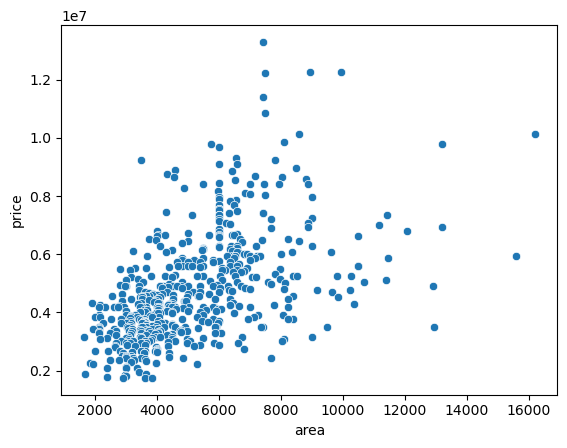

In [15]:
sns.scatterplot(x='area', y='price', data=df)
plt.show()

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2: {r2:.4f}")
print(f"RMSE {rmse:,.0f}")

R^2: 0.6495
RMSE 1,331,071


In [17]:
df['price'].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"R^2: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:,.0f}")

R^2: 0.6128
RMSE: 1,398,901


In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(f"Best CV R^2: {grid_search.best_score_:.4f}")

{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 500}
Best CV R^2: 0.6087


In [21]:
df['area_per_bedroom'] = df['area'] / df['bedrooms']

In [24]:
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")

R²: 0.6495
RMSE: 1,331,071


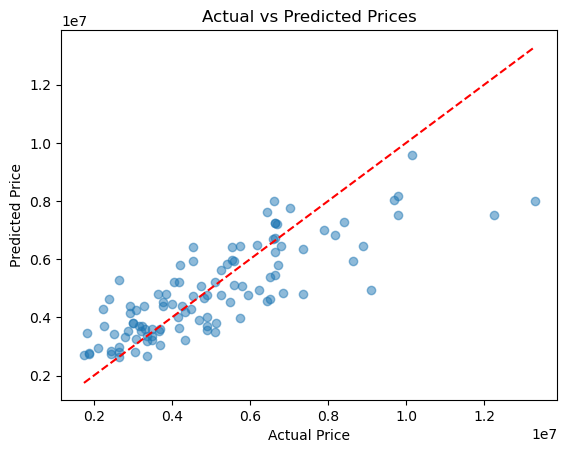

In [26]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show() 

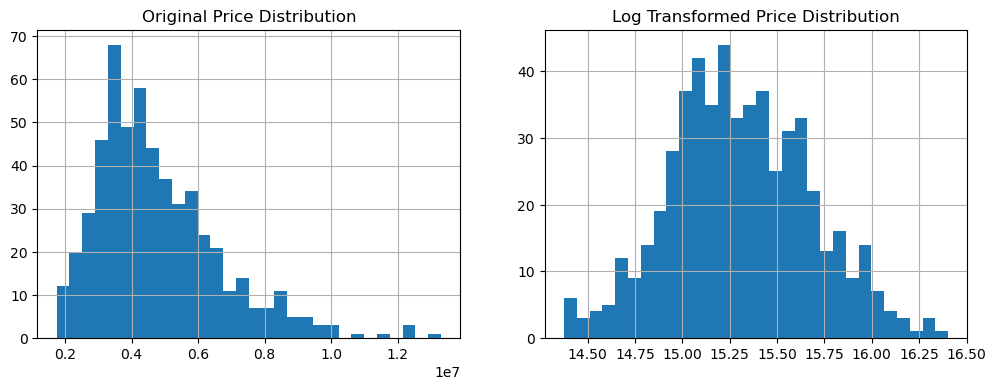

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['price'].hist(ax=axes[0], bins=30)
axes[0].set_title('Original Price Distribution')

np.log(df['price']).hist(ax=axes[1], bins=30)
axes[1].set_title('Log Transformed Price Distribution')

plt.show()

In [29]:
y_log = np.log(df['price'])
X = df.drop('price', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_log = lr.predict(X_test)

y_pred = np.exp(y_pred_log)
y_test = np.exp(y_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:,.0f}")

R^2: 0.6509
RMSE: 1,328,332


In [30]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LinearRegression(), X, y_log, cv=5, scoring='r2')
print(f"CV R^2 scores: {scores}")
print(f"Mean R^2: {scores.mean():.4f}")
print(f"Std: {scores.std():.4f}")

CV R^2 scores: [ -2.78582239  -5.85387809 -12.35295349 -10.42271644  -3.76416617]
Mean R^2: -7.0359
Std: 3.7391


In [31]:
print(X.shape)
print(y_log.shape)
print(X.head())

(545, 14)
(545,)
   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  7420         4          2        3         1          0         0   
1  8960         4          4        4         1          0         0   
2  9960         3          2        2         1          0         1   
3  7500         4          2        2         1          0         1   
4  7420         4          1        2         1          1         1   

   hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  \
0                0                1        2         1                 3   
1                0                1        3         0                 3   
2                0                0        2         1                 2   
3                0                1        3         1                 3   
4                0                1        2         0                 3   

   area_per_bedroom  total_rooms  
0            1855.0            6  
1            2240.0    

In [32]:
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus', 'area_per_bedroom', 'total_rooms']


In [33]:
print(X.isnull().sum())
print(np.isinf(X).sum())

area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
area_per_bedroom    0
total_rooms         0
dtype: int64
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
area_per_bedroom    0
total_rooms         0
dtype: int64


In [34]:
y_original = df['price']
scores_original = cross_val_score(LinearRegression(), X, y_original, cv=5, scoring='r2')
print(f"CV R² scores: {scores_original}")
print(f"Mean R²: {scores_original.mean():.4f}")

CV R² scores: [ -1.92883966  -5.24711692 -15.92857437 -20.71206192  -5.30176797]
Mean R²: -9.8237


In [35]:
print(X.describe())

               area    bedrooms   bathrooms     stories    mainroad  \
count    545.000000  545.000000  545.000000  545.000000  545.000000   
mean    5150.541284    2.965138    1.286239    1.805505    0.858716   
std     2170.141023    0.738064    0.502470    0.867492    0.348635   
min     1650.000000    1.000000    1.000000    1.000000    0.000000   
25%     3600.000000    2.000000    1.000000    1.000000    1.000000   
50%     4600.000000    3.000000    1.000000    2.000000    1.000000   
75%     6360.000000    3.000000    2.000000    2.000000    1.000000   
max    16200.000000    6.000000    4.000000    4.000000    1.000000   

        guestroom    basement  hotwaterheating  airconditioning     parking  \
count  545.000000  545.000000       545.000000       545.000000  545.000000   
mean     0.177982    0.350459         0.045872         0.315596    0.693578   
std      0.382849    0.477552         0.209399         0.465180    0.861586   
min      0.000000    0.000000         0.0000

In [36]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(LinearRegression(), X, y_original, cv=kf, scoring='r2')
print(f"CV R² scores: {scores}")
print(f"Mean R²: {scores.mean():.4f}")

CV R² scores: [0.65126185 0.7149521  0.48931029 0.65957698 0.64917961]
Mean R²: 0.6329


In [37]:
scores_log = cross_val_score(LinearRegression(), X, y_log, cv=kf, scoring='r2')
print(f"CV R² scores: {scores_log}")
print(f"Mean R²: {scores_log.mean():.4f}")

CV R² scores: [0.65609527 0.7300202  0.55908909 0.70390315 0.64402051]
Mean R²: 0.6586


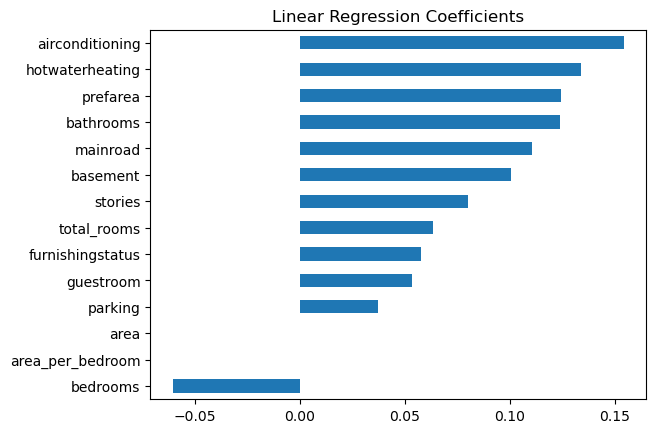

In [38]:
coefficients = pd.Series(lr.coef_, index=X.columns)
coefficients.sort_values().plot(kind='barh')
plt.title('Linear Regression Coefficients')
plt.show()

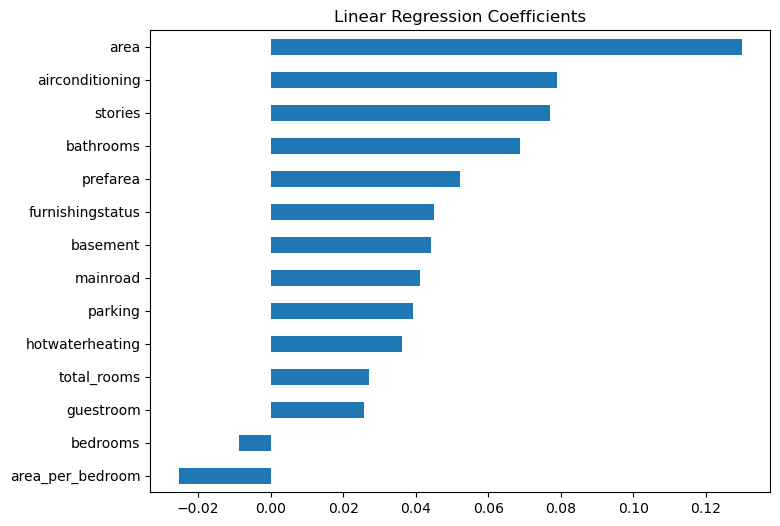

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

lr_scaled = LinearRegression()
lr_scaled.fit(X_scaled, y_log)

coefficients = pd.Series(lr_scaled.coef_, index=X.columns)
coefficients.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Linear Regression Coefficients')
plt.show()

In [42]:
from sklearn.linear_model import Ridge, Lasso

alphas = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

ridge_cv = GridSearchCV(Ridge(), alphas, cv=kf, scoring='r2')
ridge_cv.fit(X_scaled, y_log)

lasso_cv = GridSearchCV(Lasso(), alphas, cv=kf, scoring='r2')
lasso_cv.fit(X_scaled, y_log)

print(f"Best Ridge alpha: {ridge_cv.best_params_}, R^2: {ridge_cv.best_score_:.4f}")
print(f"Best Lasso alpha: {lasso_cv.best_params_}, R^2: {lasso_cv.best_score_:.4f}")

Best Ridge alpha: {'alpha': 10}, R^2: 0.6594
Best Lasso alpha: {'alpha': 0.01}, R^2: 0.6589


In [43]:
lasso_best = lasso_cv.best_estimator_
coefficients_lasso = pd.Series(lasso_best.coef_, index=X.columns)
print(coefficients_lasso.sort_values())
print(f"\nFeatures eliminated: {(coefficients_lasso == 0).sum()}")

bedrooms            0.000000
area_per_bedroom    0.000000
guestroom           0.022318
hotwaterheating     0.025531
total_rooms         0.033916
parking             0.035293
mainroad            0.036496
basement            0.037182
furnishingstatus    0.040286
prefarea            0.047855
bathrooms           0.062998
stories             0.070744
airconditioning     0.073773
area                0.104772
dtype: float64

Features eliminated: 2


In [44]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_l, y_test_l = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10),
    'Lasso': Lasso(alpha=0.01)
}

for name, model in models.items():
    model.fit(X_train_s, y_train_l)
    y_pred = np.exp(model.predict(X_test_s))
    y_actual = np.exp(y_test_l)
    r2 = r2_score(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    print(f"{name}: R²={r2:.4f}, RMSE={rmse:,.0f}")

Linear Regression: R²=0.6509, RMSE=1,328,332
Ridge: R²=0.6484, RMSE=1,333,059
Lasso: R²=0.6280, RMSE=1,371,169
